# Градиентный бустинг


Работать будем с набором данных о грибах, в котором собраны признаки внешнего вида и среды обитания разных грибов. Ваша задача — построить модель, которая сможет определять, съедобен гриб или ядовит.

**Описание признаков**

Этот датасет составлен на основе известного набора данных с Kaggle: [Mushroom Attributes Dataset](https://www.kaggle.com/datasets/ulrikthygepedersen/mushroom-attributes)

| Признак                  | Описание                                                                                                                                                               |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| cap-texture        | текстура поверхности шляпки (a — гладкая, b — волокнистая, c — чешуйчатая, d — бархатистая, e — морщинистая, f — зернистая, g — кожистая, h — липкая, i — матовая, j — блестящая, k — сетчатая, l — пористая, m — волнистая, n — пятнистая, o — ребристая, p — шероховатая, q — плотная, r — рыхлая, s — слоистая) |
| spore-pattern      | характер распределения спор (a — равномерный, b — редкий, c — плотный, d — кольцевой, e — радиальный, f — пятнистый, g — полосчатый, h — сетчатый, i — кластерный, j — случайный, k — концентрический, l — разреженный, m — волнообразный, n — диагональный, o — смешанный) |
| stem-flexibility   | гибкость ножки гриба (a — очень жесткая, b — жесткая, c — умеренно жесткая, d — слегка гибкая, e — гибкая, f — очень гибкая, g — упругая, h — мягкая, i — ломкая, j — эластичная) |
| ring-thickness     | толщина кольца на ножке (a — тонкое, b — среднее, c — толстое) |
| cap-shape                | форма шляпки (b — колокольчик, c — конический, x — выпуклый, f — плоский, k — с бугорком, s — утопленный)                                                                |
| cap-surface              | поверхность шляпки (f — волокнистая, g — канавки, y — чешуйчатая, s — гладкая)                                                                                         |
| cap-color                | цвет шляпки (n — коричневый, b — желтовато-коричневый, c — корица, g — серый, r — зелёный, p — розовый, u — фиолетовый, e — красный, w — белый, y — желтый)            |
| gill-attachment          | тип прикрепления пластинок (a — прикреплено, d — нисходящее, f — свободное, n — зубчатое)                                                                              |
| stalk-shape              | форма ножки (e — утолщение, t — сужение)                                                                                                                               |
| veil-type                | тип завесы (p — частичная, u — универсальная)                                                                                                                          |
| veil-color               | цвет завесы (n — коричневый, o — оранжевый, w — белый, y — жёлтый)                                                                                                     |
| ring-number              | количество колец (n — нет, o — одно, t — два)                                                                                                                          |
| population               | тип популяции (a — многочисленная, c — сгруппированная, n — обычная, s — рассеянная, v — несколько, y — одиночная)                                                     |
| habitat                  | среда обитания (g — трава, l — листья, m — луга, p — тропинки, u — город, w — отходы, d — леса)                                                                        |

Каждая строка описывает один вид гриба.

**Таргет** — столбец `class`:

* `e` — съедобный гриб
* `p` — ядовитый гриб



In [1]:
 pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [2]:
# pip install phik

In [3]:
pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 9.8 MB/s eta 0:00:00


In [4]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import optuna
from catboost import Pool, CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.datasets import fetch_openml
from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeRegressor


import catboost as cb
import xgboost as xgb
import lightgbm as lgb

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", 10000)

## Задание 1

Эта часть, как всегда, посвящена знакомству с данными:

* Загрузите данные, посмотрите на структуру, количество строк и столбцов.
* Проверьте наличие пропусков NaN и типы признаков, при необходимости обработайте их.
* Проверьте наличие полных дубликатов строк в данных, при необходимости удалите их.
* Присутствуют ли столбцы с ошибочными названиями? Исправьте при наличии.

Запишите наблюдения в коротком выводе.

In [5]:
df = pd.read_csv('mushrooms.csv')

In [6]:
print(df.shape)
df.sample(3)

(8124, 15)


,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface:%3F,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
6532,b'k',b'b',b'e',b'b',b'f',b's',b'e',b'f',b't',b'p',b'w',b'o',b'v',b'd',b'p'
8082,b'o',b'a',b'g',b'c',b'k',b's',b'e',b'f',b't',b'p',b'w',b'o',b'v',b'p',b'p'
4721,b'q',b'b',b'h',b'b',b'x',b'f',b'y',b'f',b'e',b'p',b'w',b'o',b'v',b'g',b'p'


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cap-texture       8124 non-null   object
 1   spore-pattern     8124 non-null   object
 2   stem-flexibility  8124 non-null   object
 3   ring-thickness    8124 non-null   object
 4   cap-shape         8124 non-null   object
 5   cap-surface:%3F   8124 non-null   object
 6   cap-color         8124 non-null   object
 7   gill-attachment   8124 non-null   object
 8   stalk-shape       8124 non-null   object
 9   veil-type         8124 non-null   object
 10  veil-color        8124 non-null   object
 11  ring-number       8124 non-null   object
 12  population        8124 non-null   object
 13  habitat           8124 non-null   object
 14  class             8124 non-null   object
dtypes: object(15)
memory usage: 952.2+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.rename(columns={'cap-surface:%3F': 'cap-surface'}, inplace=True)

**Вывод:** (8124, 15) - количество строк и столбцов.
* Пропусков нет, тип признаков - object
* Полных дубликатов строк нет
* Исправлен столбец с ошибочными названием df['cap-surface']


## Задание 2

Исследуем поближе категориальные признаки датасета:

* Выведите уникальные значения каждого категориального признака, просмотрите их. Есть ли в датасете скрытые пропуски и неинформативные признаки? При необходимости обработайте/удалите их.
* Приведите каждое значение к одной букве, удалив всюду кавычки и `b`.
* Изучите распределения признаков, построив для каждого `countplot`. Если есть редкие категории, предложите, что с ними лучше сделать. Заодно проверьте, присутствует ли дисбаланс классов.

Запишите все мысли в выводе.

In [10]:
df.describe(include='object')

,cap-texture,spore-pattern,stem-flexibility,ring-thickness,cap-shape,cap-surface,cap-color,gill-attachment,stalk-shape,veil-type,veil-color,ring-number,population,habitat,class
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,19,15,10,3,6,4,10,2,2,1,4,4,6,7,2
top,b'a',b'o',b'i',b'c',b'x',b'y',b'n',b'f',b't',b'p',b'w',b'o',b'v',b'd',b'e'
freq,435,548,820,2723,3656,3244,2284,7914,4608,8124,7924,7487,4040,3148,4208


In [11]:
# Столбцы имеют мало уникальных значений, удалим столбцы:
columns_to_delete = ['veil-type'] # , 'gill-attachment', 'veil-color']
df.drop(columns=columns_to_delete, axis=1, inplace=True)

In [12]:
# В столбце ring-number есть вот такое значение "b'?'"
for el in df.columns:
  print(df[el].unique())

["b'j'" "b'm'" "b'e'" "b'b'" "b'h'" "b'p'" "b'n'" "b'a'" "b'l'" "b'g'"
 "b'r'" "b's'" "b'f'" "b'i'" "b'd'" "b'k'" "b'c'" "b'q'" "b'o'"]
["b'i'" "b'g'" "b'c'" "b'f'" "b'a'" "b'j'" "b'd'" "b'm'" "b'o'" "b'e'"
 "b'b'" "b'n'" "b'h'" "b'l'" "b'k'"]
["b'a'" "b'f'" "b'e'" "b'j'" "b'h'" "b'c'" "b'b'" "b'i'" "b'g'" "b'd'"]
["b'a'" "b'c'" "b'b'"]
["b'x'" "b'b'" "b's'" "b'f'" "b'k'" "b'c'"]
["b's'" "b'y'" "b'f'" "b'g'"]
["b'n'" "b'y'" "b'w'" "b'g'" "b'e'" "b'p'" "b'b'" "b'u'" "b'c'" "b'r'"]
["b'f'" "b'a'"]
["b'e'" "b't'"]
["b'w'" "b'n'" "b'o'" "b'y'"]
["b'o'" "b'?'" "b't'" "b'n'"]
["b's'" "b'n'" "b'a'" "b'v'" "b'y'" "b'c'"]
["b'u'" "b'g'" "b'm'" "b'd'" "b'p'" "b'w'" "b'l'"]
["b'p'" "b'e'"]


In [13]:
# Очистка байтовых строк
def clean_bytes(x):
    if isinstance(x, str) and x.startswith("b'") and x.endswith("'"):
        return x[2:-1]
    return x
df = df.map(clean_bytes)

In [14]:
# Удаление строк с '?'
df = df[~df.isin(['?']).any(axis=1)]

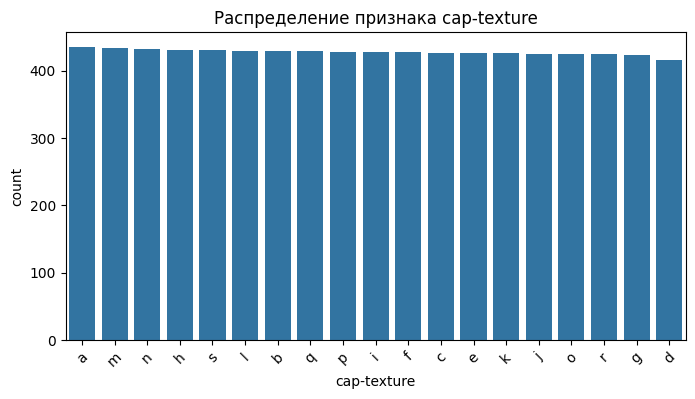

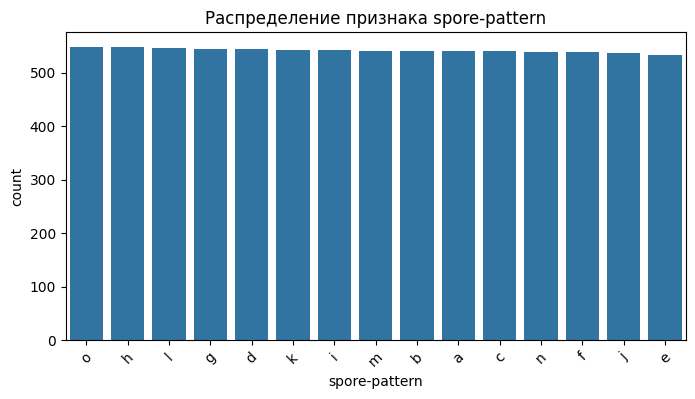

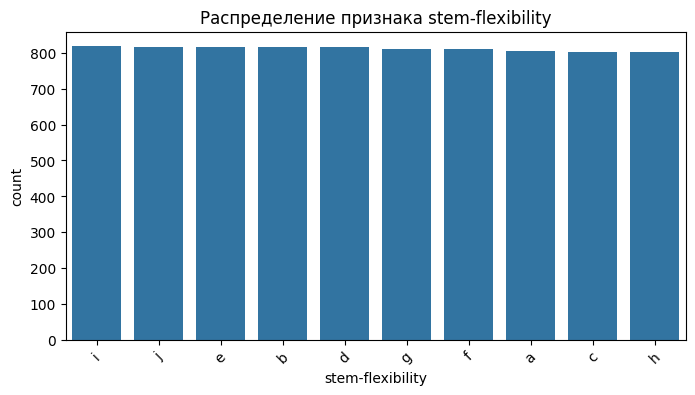

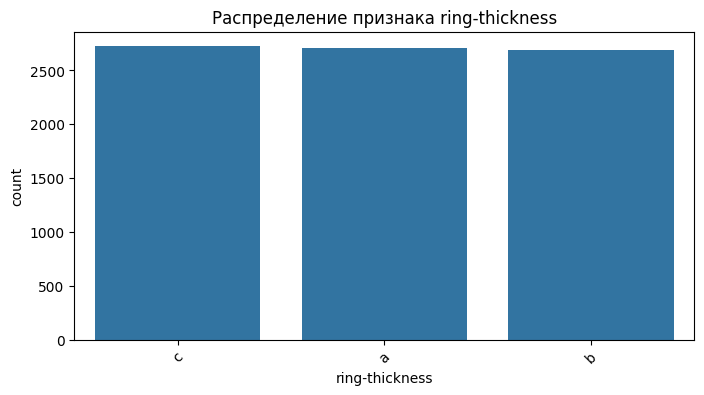

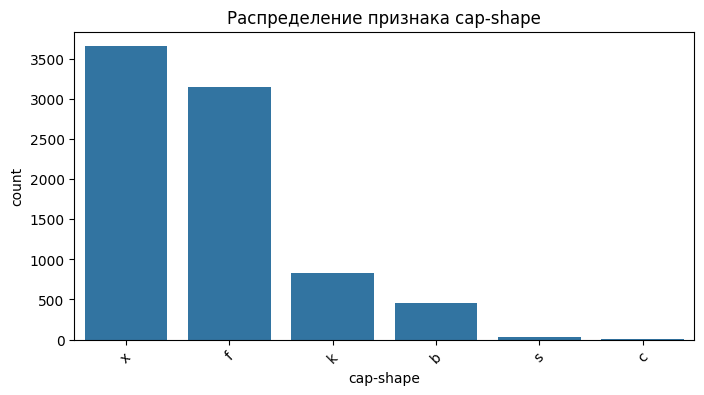

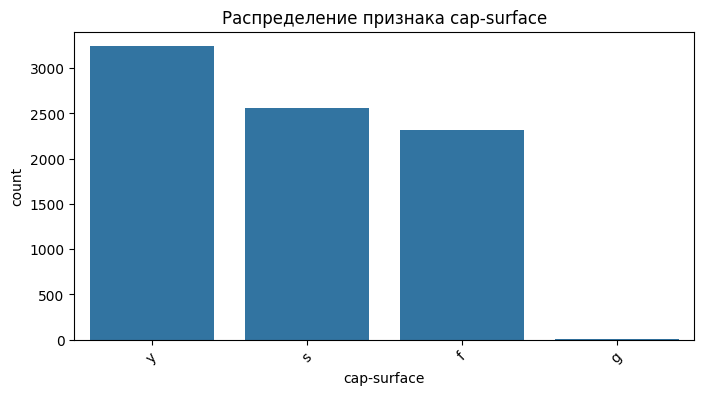

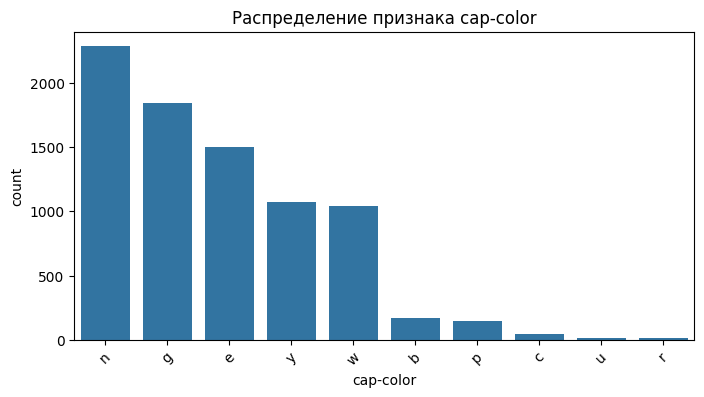

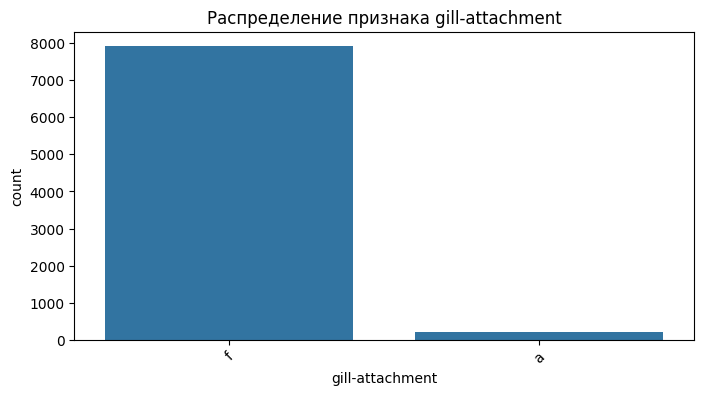

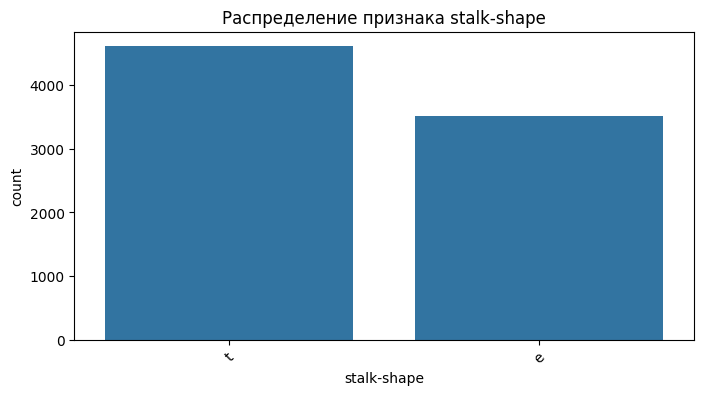

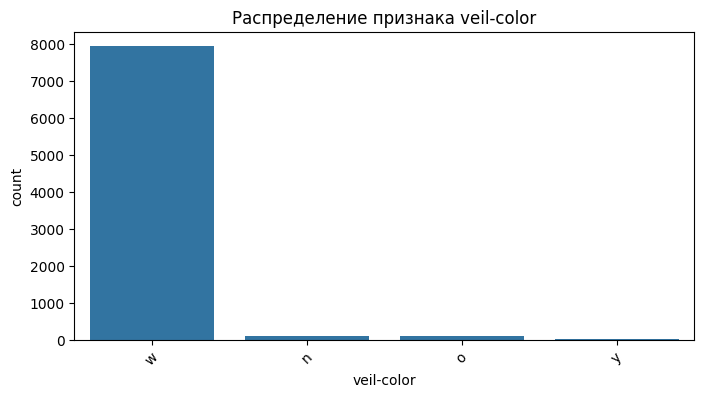

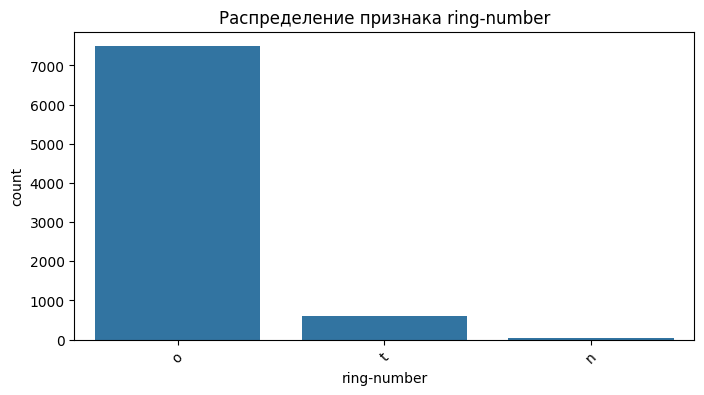

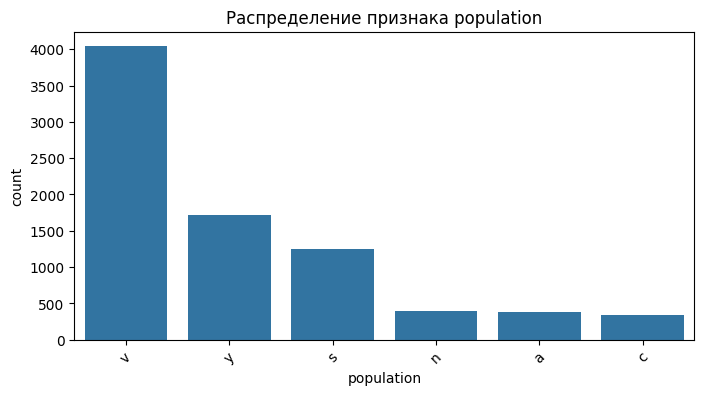

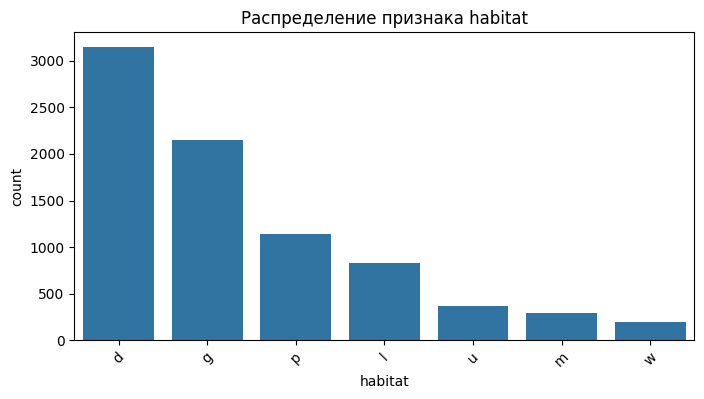

In [15]:
for col in df.columns:
    if col != 'class':
        plt.figure(figsize=(8,4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Распределение признака {col}')
        plt.xticks(rotation=45)
        plt.show()

In [16]:
# Удаляем малочастотные классы

df.drop(df[df['ring-number'] == 'n'].index, inplace=True)
df.drop(df[df['cap-shape'] == 's'].index, inplace=True)
df.drop(df[df['cap-shape'] == 'c'].index, inplace=True)
df.drop(df[df['cap-surface'] == 'g'].index, inplace=True)

In [17]:
# Дисбаланса по классам таргета нет
print(df['class'].value_counts(normalize=True))

class
e    0.518762
p    0.481238
Name: proportion, dtype: float64


In [18]:
# Объединяем классы ['b', 'p', 'c', 'u', 'r'] в прочее
# Объединение редких значений в новую категорию (менее 10% от общего числа)
value_counts = df['cap-color'].value_counts()
rare_values = value_counts[value_counts < 0.1 * len(df)].index
#print(rare_values)
df['cap-color'] = df['cap-color'].apply(lambda x: 'o' if x in rare_values else x)

**Вывод:**
* Столбцы имеют мало уникальных значений, удалим столбцы: ['veil-type', 'gill-attachment', 'veil-color']
* В столбце ring-number есть вот такое значение "b'?'", удалим такие значения
* Удаляем малочастотные классы
* Дисбаланса по классам таргета нет
* Объединяем классы ['b', 'p', 'c', 'u', 'r'] в прочее
* Приведены значения к одной букве, удалив всюду кавычки и `b`.


## Задание 3

Проверим корреляции между признаками и таргетом:
* Так как данные состоят только из категориальных признаков, в первом приближении можно закодировать их через `OrdinalEncoder`.
* Выберите тип корреляции, которую будете рассчитывать из тех, что мы изучали, с учетом типов признаков.
* Визуализируйте матрицу корреляций на тепловой карте для наглядности. Что можно по ней сказать?

Как всегда, запишите все наблюдения в выводе.

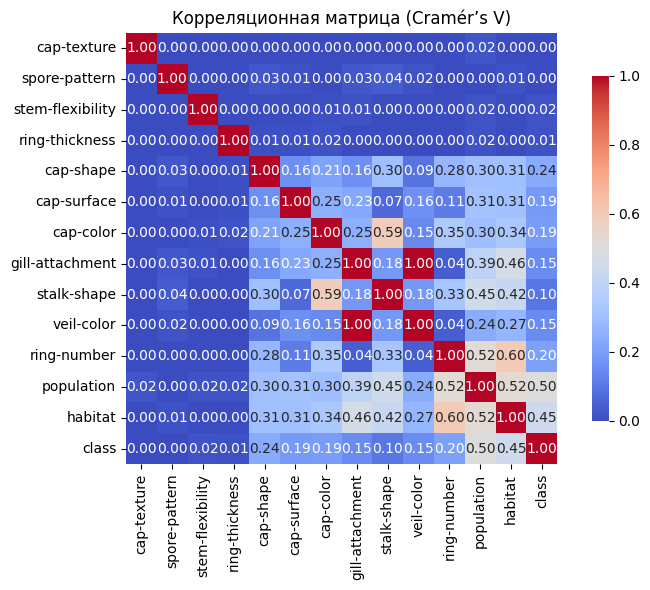

In [19]:
# Расчет корелляции методом Крамера:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cols = df.columns
n = len(cols)
cramers_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            cramers_matrix[i, j] = 1.0
        else:
            # Строим таблицу сопряжённости для двух категориальных переменных
            ct = pd.crosstab(df.iloc[:, i], df.iloc[:, j])
            cramers_matrix[i, j] = cramers_v(ct.values)

# Преобразуем в DataFrame для удобства
cramers_df = pd.DataFrame(cramers_matrix, index=cols, columns=cols)

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_df, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица (Cramér’s V)')
plt.tight_layout()
plt.show()

In [20]:
# Для удобства расчётов закодируем все признаки (включая целевую переменную) числовыми метками с помощью OrdinalEncoder

X = df.drop('class', axis=1)
y = df['class']

encoder = OrdinalEncoder(dtype=int)
X_enc = pd.DataFrame(encoder.fit_transform(X), columns=X.columns)
y_enc = pd.Series(encoder.fit_transform(y.values.reshape(-1, 1)).ravel(), name='class')

# Объединяем в один DataFrame для расчёта матрицы
df1 = pd.concat([X_enc, y_enc.to_frame()], axis=1)


**Вывод:**
- Матрица корреляции составлена для категориальных признаков методом Крамера.
- Наибольшую корреляцию имеют признаки stalk-shape&cap-color = 0.59
habitat&ring-number = 0.6 , что не больше 0,7, поэтому удалять признаки пока не будем.
- Категориальные признаки закодированы методом OrdinalEncoder.

## Задание 4
Переходим к финальной части — итоговой подготовке данных для подачи на вход моделям:
* Закодируйте категориальные признаки уже подходящим способом, обоснуйте выбор. Сделайте так, чтобы после кодирования получился пандас-датафрейм с понятными названиями столбцов, **избегая утечки данных** между тренировочной и тестовой выборками.
* Не забывайте, что таргет тоже должен быть закодирован.
* Еще раз убедитесь, что удалили/обработали все те неприятности, что выявили ранее, если они остались.
* Разбейте данные на тренировочную, валидационную и тестовую выборки, установите соотношение 80/10/10 и random_state=42.

In [21]:
X = df.drop('class', axis=1)
y = df['class']

# Разбиение: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Проверка размеров
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (6438, 13), Val: (805, 13), Test: (805, 13)


In [22]:
# Создаём и подгоняем OneHotEncoder на train
ohe = OneHotEncoder(sparse_output=False)#, handle_unknown='ignore')
ohe.fit(X_train)

X_train_enc = ohe.transform(X_train)
X_val_enc = ohe.transform(X_val)
X_test_enc = ohe.transform(X_test)

# Получаем названия столбцов
feature_names = ohe.get_feature_names_out(X.columns)

X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_val_enc = pd.DataFrame(X_val_enc, columns=feature_names, index=X_val.index)
X_test_enc = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

print(f"После кодирования: {X_train_enc.shape[1]} признаков")

После кодирования: 83 признаков


In [23]:
le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Преобразуем в Series для удобства (индексы сохраняем)
y_train_enc = pd.Series(y_train_enc, index=y_train.index, name='class')
y_val_enc = pd.Series(y_val_enc, index=y_val.index, name='class')
y_test_enc = pd.Series(y_test_enc, index=y_test.index, name='class')

In [24]:
print("Распределение классов (доля класса 1):")
print(f"Train: {y_train_enc.mean():.3f}")
print(f"Val:   {y_val_enc.mean():.3f}")
print(f"Test:  {y_test_enc.mean():.3f}")

Распределение классов (доля класса 1):
Train: 0.481
Val:   0.482
Test:  0.481


**Вывод:**
Полученные датафреймы X_train_enc, X_val_enc, X_test_enc и соответствующие целевые переменные готовы для обучения моделей машинного обучения. One-hot кодирование позволило сохранить всю информацию о категориях, не внося искажений, а разделение данных выполнено с учётом требований к валидации и тестированию. Целевая переменная закодирована - LabelEncoder.


## Задание 5
Приступаем к моделированию. Прежде чем обучать модели, важно определиться с метриками качества. Подумайте, какие аспекты качества модели важны в данной задаче, и запишите рассуждения:
* На какую метрику вы бы ориентировались при сравнении разных моделей между собой?
* Какую метрику или набор метрик вы бы выбрали для презентации результатов бизнесу, учитывая практические ограничения и последствия ошибок модели?

**Вывод:**
При решении этой задачи критически важно учитывать последствия ошибок модели. Ошибка, при которой ядовитый гриб классифицируется как съедобный (False Positive для класса «ядовитый» или False Negative для класса «съедобный»), может привести к серьёзным последствиям для здоровья. Обратная ошибка (съедобный гриб признан ядовитым) менее опасна — это лишь упущенная возможность.

1. При сравнении моделей между собой метрика должна отражает способность модели минимизировать самые опасные ошибки. Подходящим выбором является полнота (recall) для класса ядовитых грибов, которая показывает долю истинно ядовитых грибов правильно идентифицированных. Чем выше recall, тем меньше шансов пропустить опасный гриб.\
\
Однако ориентироваться только на recall может быть недостаточно, так как модель может достичь высокого recall, классифицируя все грибы как ядовитые (что даст recall=1, но precision для ядовитых будет низким, и много съедобных грибов будут ошибочно отбракованы). Чтобы учесть и точность, можно использовать F₁-меру для класса ядовитых, где вес recall выше. В условиях баланса классов и отсутствия явного дисбаланса, F₁ для ядовитых даст разумный компромисс.

2. Метрики для презентации бизнесу
Для бизнес-презентации важно не только показать качество модели, но и объяснить практические последствия её использования. Представим следующий набор метрик:

- Confusion matrix (матрица ошибок) — наглядно показывает, сколько грибов каждого типа были правильно или неправильно классифицированы, чтобы увидеть абсолютные числа ошибок.

- Precision и recall для каждого класса:
Precision для съедобных: доля истинно съедобных среди всех грибов, которые модель назвала съедобными. Это важно для уверенности, что рекомендованный гриб безопасен.
- Recall для ядовитых: доля выявленных ядовитых грибов. Это ключевой показатель безопасности.
- ROC-AUC — может быть полезна для демонстрации общего качества модели, но не даёт прямого понимания практических ошибок.
- Также можно рассчитать F₁-меру для класса ядовитых как единый показатель, но бизнесу лучше показать отдельно precision и recall, чтобы подчеркнуть компромисс.



## Задание 6
Теперь попробуйте на дефолтных гиперпараметрах (или, по крайней мере, без особого подбора) обучить следующие модели:
* градиентный бустинг, реализованный вручную;
* `GradientBoostingClassifier` из `sklearn`.

Рассчитайте выбранные метрики на тренировочной и тестовой выборке (возьмите для дальнейшего единообразия именно тестовую, валидационную пока оставьте). Что можно сказать о качестве и недо-/переобучении? Замерьте также время работы моделей (обучения и инференса).

In [25]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def _init_F0(y: np.ndarray, eps: float = 1e-6) -> float:
    p0 = np.clip(np.mean(y), eps, 1 - eps)
    return np.log(p0 / (1 - p0))

In [26]:
def fit_gradient_boosting(
    X,
    y,
    n_estimators: int = 100,
    learning_rate: float = 0.1,
    max_depth: int = 3,
    min_samples_leaf: int = 5,
    verbose: bool = False
):
    X_arr = np.asarray(X)
    y_arr = np.asarray(y)

    F0 = _init_F0(y_arr)
    F = np.full(len(y_arr), fill_value=F0, dtype=float)

    trees = []
    for m in range(n_estimators):
        p = sigmoid(F)               # текущие вероятности
        residual = y_arr - p         # negative gradient для log-loss

        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=0
        )
        tree.fit(X_arr, residual)    # учим дерево предсказывать остатки
        update = tree.predict(X_arr)
        F = F + learning_rate * update

        trees.append(tree)

        if verbose and (m + 1) % 10 == 0:
            auc = roc_auc_score(y_arr, sigmoid(F))
            print(f"iter={m+1}  AUC={auc:.4f}")

    model = {
        "F0": float(F0),
        "trees": trees,
        "learning_rate": float(learning_rate)
    }
    return model

In [27]:
def decision_function(model, X):
    X_arr = np.asarray(X)
    F = np.full(X_arr.shape[0], fill_value=model["F0"], dtype=float)
    for tree in model["trees"]:
        F += model["learning_rate"] * tree.predict(X_arr)
    return F

def predict_proba(model, X):
    F = decision_function(model, X)
    p = sigmoid(F)
    return np.vstack([1 - p, p]).T

def predict(model, X, threshold: float = 0.5):
    probs = predict_proba(model, X)[:, 1]
    return (probs >= threshold).astype(int)

In [28]:
# Обучаем
model = fit_gradient_boosting(
    X_train_enc, y_train_enc,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=5,
    verbose=True
)

# Предсказываем
probs_train = predict_proba(model, X_train_enc)[:, 1]
preds_train = predict(model, X_train_enc)
probs_test = predict_proba(model, X_test_enc)[:, 1]
preds_test = predict(model, X_test_enc)

# print('Manual GB AUC train:', roc_auc_score(y_train_enc, probs_train))
# print('Manual GB AUC test:', roc_auc_score(y_test_enc, probs_test))
# print('Manual GB Accuracy train:', accuracy_score(y_train_enc, preds_train))
# print('Manual GB Accuracy test:', accuracy_score(y_test_enc, preds_test))
print('f1 train:', f1_score(y_train_enc, preds_train))
print('f1 test:', f1_score(y_test_enc, preds_test))
print()
print('recall train',  recall_score(y_train_enc, preds_train, average='weighted'))
print('recall test',  recall_score(y_train_enc, preds_train, average='weighted'))
print('precision train',  precision_score(y_train_enc, preds_train, average='weighted'))
print('precision test',  precision_score(y_test_enc, preds_test, average='weighted'))


iter=10  AUC=0.9195
iter=20  AUC=0.9298
iter=30  AUC=0.9423
iter=40  AUC=0.9494
iter=50  AUC=0.9518
iter=60  AUC=0.9561
iter=70  AUC=0.9591
iter=80  AUC=0.9589
iter=90  AUC=0.9582
iter=100  AUC=0.9613
f1 train: 0.907030223390276
f1 test: 0.8941798941798942

recall train 0.9120844982913948
recall test 0.9120844982913948
precision train 0.912439284334949
precision test 0.9012555784569756


Обучаем `GradientBoostingClassifier` из `sklearn`

In [29]:
# Обучаем GradientBoostingClassifier из sklearn
model_skl = GradientBoostingClassifier(
    n_estimators=100,     # Количество деревьев
    learning_rate=0.1,    # Темп обучения
    max_depth=3,          # Макс. глубина деревьев
    subsample=1.0,        # Использовать все данные для каждого дерева (пока)
    random_state=42
)
model_skl.fit(X_train_enc, y_train_enc)

# Предсказываем
probs_train = model_skl.predict_proba(X_train_enc)[:, 1]
preds_train = model_skl.predict(X_train_enc)
probs_test = model_skl.predict_proba(X_test_enc)[:, 1]
preds_test = model_skl.predict(X_test_enc)

print('f1 train:', f1_score(y_train_enc, preds_train))
print('f1 test:', f1_score(y_test_enc, preds_test))
print()
print('recall train',  recall_score(y_train_enc, preds_train, average='weighted'))
print('recall test',  recall_score(y_train_enc, preds_train, average='weighted'))
print('precision train',  precision_score(y_train_enc, preds_train, average='weighted'))
print('precision test',  precision_score(y_test_enc, preds_test, average='weighted'))

f1 train: 0.9398889251878471
f1 test: 0.9236842105263158

recall train 0.9428393911152532
recall test 0.9428393911152532
precision train 0.943024705361079
precision test 0.928373825343169


**Вывод:**
Обе модели показали достаточно высокий результат без подбора гиперпараметров.
`GradientBoostingClassifier` из `sklearn` показал лучше результат f1 test: 0.93, по сравнению с ручной реализацией f1 test: 0.88.
Recall получился одинаковым на трейне и тесте, но это не говорит о переобучении, так как другие метрики отличаются и имеем высокий показатель на тесте.
Скорость выполнения достаточно высокая, до 1 минуты.


## Задание 7
Теперь попробуйте на дефолтных гиперпараметрах обучить трех китов современных градиентных бустингов:
* CatBoost;
* XGBoost;
* LightGBM.

Также замерьте качество и время работы (обучения и инференса), сделайте итоговый вывод. Какую модель рекомендовали бы для продакшена?

### 1. XGBoost

In [30]:
dtrain = xgb.DMatrix(X_train_enc, label=y_train_enc)
dval = xgb.DMatrix(X_val_enc, label=y_val_enc)
dtest = xgb.DMatrix(X_test_enc, label=y_test_enc)

In [31]:
# # сетка гиперпараметров
# xgb_params = {
#     'max_depth': 6,            # максимальная глубина дерева
#     'eta': 0.1,                # learning rate, шаг обновления весов
#     'subsample': 0.8,          # доля объектов, используемых для каждого дерева
#     'colsample_bytree': 0.8,   # доля признаков, используемых при построении дерева
#     'gamma': 0,                # минимальное снижение функции потерь для разбиения (больше gamma -> меньше переобучение)
#     'alpha': 0,                # l1-регуляризация весов листьев
#     'lambda': 1,               # l2-регуляризация весов листьев
#     'objective': 'binary:logistic',  # функция потерь (здесь - для бинарной классификации)
#     'eval_metric': 'auc',      # метрика качества на валидации
#     'seed': 42                 # фиксирует воспроизводимость
# }

In [32]:
xgb_params = {
    # базовая сложность модели
    'max_depth': 6,                 # максимальная глубина дерева
    'eta': 0.05,                    # learning rate (меньше -> стабильнее, но больше деревьев)

    # стохастичность (борется с переобучением)
    'subsample': 0.8,               # доля объектов для каждого дерева
    'colsample_bytree': 0.8,        # доля признаков на дерево

    # контроль разбиений
    'gamma': 1.0,                   # минимальное улучшение loss для сплита
    'min_child_weight': 5,          # минимальная сумма hessian в листе

    # регуляризация
    'alpha': 0.5,                   # l1-регуляризация весов листьев
    'lambda': 1.0,                  # l2-регуляризация весов листьев

    # работа с дисбалансом
    #'scale_pos_weight': scale_pos_weight,  # балансировка классов

    # валидация и метрика
    'objective': 'binary:logistic', # бинарная классификация
    'eval_metric': 'auc',           # метрика на валидации

    # вычислительные параметры
    'tree_method': 'hist',          # более быстрый гистограммный алгоритм
    'nthread': -1,                  # использовать все доступные ядра

    # воспроизводимость
    'seed': 42
}

In [33]:
%%time
evals_result = {}
xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=1000,                  # максимум деревьев
    evals=[(dtrain, 'train'), (dval, 'valid')],  # мониторинг на train и valid
    early_stopping_rounds=50,              # остановка при отсутствии улучшения
    evals_result=evals_result,             # сохраняем историю обучения
    verbose_eval=100                       # лог каждые 100 итераций
)

[0]	train-auc:0.97940	valid-auc:0.97766
[100]	train-auc:0.99369	valid-auc:0.99320
[200]	train-auc:0.99537	valid-auc:0.99456
[296]	train-auc:0.99561	valid-auc:0.99471
CPU times: user 5.12 s, sys: 24.1 ms, total: 5.14 s
Wall time: 6.68 s


In [34]:
# 1. Получаем ВЕРОЯТНОСТИ для всех выборок
probs_train = xgb_model.predict(dtrain)
probs_val = xgb_model.predict(dval)
probs_test = xgb_model.predict(dtest)

# 2. Считаем ROC AUC (подаем сырые вероятности)
print("Train AUC:", roc_auc_score(y_train_enc, probs_train))
print("Valid AUC:", roc_auc_score(y_val_enc, probs_val))
print("Test AUC:", roc_auc_score(y_test_enc, probs_test))
print()

# 3. Переводим вероятности в жесткие классы (порог 0.5)
# Если вероятность > 0.5, считаем что это 1, иначе 0
xgb_train_pred = (probs_train > 0.5).astype(int)
xgb_val_pred = (probs_val > 0.5).astype(int)
xgb_test_pred = (probs_test > 0.5).astype(int)

# 4. Считаем F1 (подаем жесткие классы 0/1)
print('F1 train:', f1_score(y_train_enc, xgb_train_pred))
print('F1 val:', f1_score(y_val_enc, xgb_val_pred))
print('F1 test:', f1_score(y_test_enc, xgb_test_pred))

Train AUC: 0.9956149515043509
Valid AUC: 0.9947093871294717
Test AUC: 0.9893920848633211

F1 train: 0.9548834903321765
F1 val: 0.9546666666666667
F1 test: 0.9296148738379814


In [35]:
# xgb_train_pred = xgb_model.predict(dtrain)
# xgb_val_pred = xgb_model.predict(dval)
# xgb_test_pred = xgb_model.predict(dtest)

# print("Train AUC:", roc_auc_score(y_train_enc, xgb_train_pred))
# print("Valid AUC:", roc_auc_score(y_val_enc, xgb_val_pred))
# print("Test AUC:", roc_auc_score(y_test_enc, xgb_test_pred))
# print()

# # probs_train = xgb_model.predict_proba(dtrain, X_train_enc)[:, 1]
# # probs_test = xgb_model.predict_proba(dtest, X_test_enc)[:, 1]

# # print("Best iteration:", xgb_model.best_iteration)
# # print('F1 train:', f1_score(y_train_enc, probs_train))
# # print('F1 test:', f1_score(y_test_enc, probs_test))

# xgb_train_pred = (xgb_model.predict(dtrain) > 0.5).astype(int)
# xgb_val_pred = (xgb_model.predict(dval) > 0.5).astype(int)
# xgb_test_pred = (xgb_model.predict(dtest) > 0.5).astype(int)

# print('F1 train:', f1_score(y_train_enc, xgb_train_pred))
# print('F1 test:', f1_score(y_test_enc, xgb_test_pred))

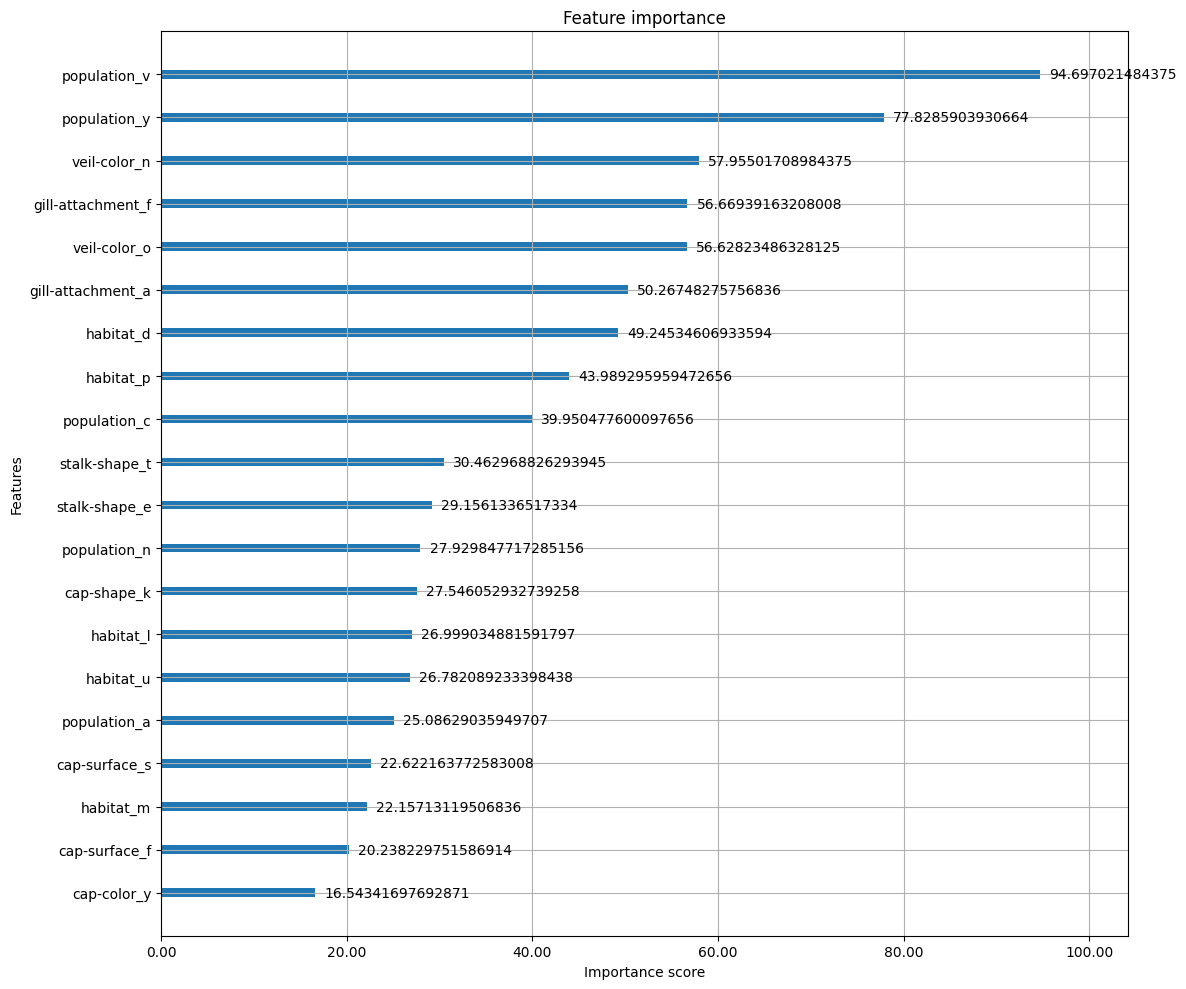

In [36]:
fig, ax = plt.subplots(figsize=(12, 10))

xgb.plot_importance(
    xgb_model,
    importance_type='gain',
    max_num_features=20,
    ax=ax
)

# формат чисел по оси X до 2 знаков
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

### 2. LightGBM


In [37]:
lgb_train = lgb.Dataset(
    X_train_enc,
    label=y_train_enc
)
lgb_valid = lgb.Dataset(
    X_val_enc,
    label=y_val_enc,
    reference=lgb_train
)
# lgb_test = lgb.Dataset(
#     X_test_enc,
#     label=y_test_enc,
#     reference=lgb_train
# )


In [38]:
# сетка гиперпараметров
lgb_params = {
    # базовая логика бустинга
    'boosting_type': 'gbdt',         # классический gradient boosting decision trees
    'objective': 'binary',           # бинарная классификация
    'metric': 'auc',                 # метрика качества

    # включаем extra trees режим (для 'boosting_type': 'gbdt')
    'extra_trees': True,          # случайный выбор порогов (меньше переобучение)

    # сложность модели
    'num_leaves': 31,                # число листьев (главный параметр сложности)
    'max_depth': -1,                 # ограничение глубины (-1 = без ограничения)
    'learning_rate': 0.05,           # шаг обучения

    # контроль разбиений
    'min_child_samples': 20,         # минимальное число объектов в листе
    'min_child_weight': 1e-3,        # минимальная сумма hessian в листе
    'min_split_gain': 0.0,           # минимальный прирост качества для сплита

    # стохастичность
    'subsample': 0.8,                # доля объектов для дерева
    'subsample_freq': 1,             # как часто применять subsample
    'feature_fraction': 0.8,         # доля признаков для дерева

    # регуляризация
    'lambda_l1': 0.5,                # l1-регуляризация
    'lambda_l2': 1.0,                # l2-регуляризация

    # дисбаланс
    #'scale_pos_weight': scale_pos_weight,  # балансировка классов

    # ускорение
    'max_bin': 255,                  # число бинов для гистограмм
    'n_jobs': -1,                    # использовать все ядра

    # воспроизводимость
    'seed': 42,
    'verbosity': -1                  # отключить лишние логи
}

In [39]:
%%time
lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    num_boost_round=2000,                         # максимум деревьев
    valid_sets=[lgb_train, lgb_valid],            # мониторинг
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),  # также добавим раннюю остановку
        lgb.log_evaluation(period=100)            # лог каждые 100 итераций
    ]
)

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.996092	valid's auc: 0.994722
[200]	train's auc: 0.997874	valid's auc: 0.994728
Early stopping, best iteration is:
[139]	train's auc: 0.997012	valid's auc: 0.994821
CPU times: user 2.95 s, sys: 28.9 ms, total: 2.98 s
Wall time: 3.12 s


In [40]:
lgb_train_pred = (lgb_model.predict(X_train_enc) > 0.5).astype(int)
lgb_val_pred = (lgb_model.predict(X_val_enc) > 0.5).astype(int)
lgb_test_pred = (lgb_model.predict(X_test_enc) > 0.5).astype(int)

print('F1 train:', f1_score(y_train_enc, lgb_train_pred))
print('F1 test:', f1_score(y_test_enc, lgb_test_pred))

F1 train: 0.9633267845448592
F1 test: 0.9363395225464191


### 3. Catboost

In [41]:
train_pool = cb.Pool(
    X_train_enc,
    label=y_train_enc
)
valid_pool = cb.Pool(
    X_val_enc,
    label=y_val_enc
)
test_pool = cb.Pool(
    X_test_enc,
    label=y_test_enc
)

In [42]:
cb_params = {
    # базовая логика
    'loss_function': 'Logloss',        # функция потерь для бинарной классификации
    'eval_metric': 'AUC',              # метрика качества

    # сложность модели
    'depth': 6,                        # глубина деревьев
    'learning_rate': 0.05,             # шаг обучения
    'iterations': 3000,                # максимум деревьев

    # регуляризация
    'l2_leaf_reg': 5.0,                # l2-регуляризация
    'random_strength': 1.0,            # шум при выборе сплитов (борьба с переобучением)
    'bagging_temperature': 1.0,        # интенсивность стохастического бутстрэпа

    # работа с дисбалансом
    #'scale_pos_weight': scale_pos_weight,  # балансировка классов

    # ускорение
    'bootstrap_type': 'Bayesian',      # байесовский бутстрэп (по умолчанию лучший)
    'task_type': 'CPU',                # можно поставить 'GPU' если доступна - обучение будет быстрее!
    'thread_count': -1,                # использовать все ядра

    # early stopping
    'od_type': 'Iter',                 # тип overfitting detector
    'od_wait': 100,                    # остановка если 100 итераций нет улучшения

    # воспроизводимость
    'random_seed': 42,
    'verbose': 200                     # лог каждые 200 итераций
}

In [43]:
%%time
cb_model = cb.CatBoostClassifier(**cb_params)

cb_model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True,      # сохраняем лучшую итерацию
    verbose=200
)

0:	test: 0.9482496	best: 0.9482496 (0)	total: 51.5ms	remaining: 2m 34s
200:	test: 0.9957663	best: 0.9958281 (168)	total: 1.1s	remaining: 15.3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9958589829
bestIteration = 204

Shrink model to first 205 iterations.
CPU times: user 1.31 s, sys: 42.4 ms, total: 1.36 s
Wall time: 1.73 s


CatBoostClassifier(bagging_temperature=1.0, bootstrap_type='Bayesian', depth=6, eval_metric='AUC', iterations=3000, l2_leaf_reg=5.0, learning_rate=0.05, loss_function='Logloss', od_type='Iter', od_wait=100, random_seed=42, random_strength=1.0, task_type='CPU', verbose=200)

In [44]:
cb_train_pred = (cb_model.predict(train_pool) > 0.5).astype(int)
cb_val_pred = (cb_model.predict(valid_pool) > 0.5).astype(int)
cb_test_pred = (cb_model.predict(test_pool) > 0.5).astype(int)

print('F1 train:', f1_score(y_train_enc, cb_train_pred))
print('F1 test:', f1_score(y_test_enc, cb_test_pred))

F1 train: 0.9612967251075091
F1 test: 0.9381720430107527


In [45]:
cb_train_pred = cb_model.predict_proba(train_pool)[:, 1]
cb_val_pred = cb_model.predict_proba(valid_pool)[:, 1]
cb_test_pred = cb_model.predict_proba(test_pool)[:, 1]

print("Best iteration:", cb_model.get_best_iteration())
print("Train AUC:", roc_auc_score(y_train_enc, cb_train_pred))
print("Valid AUC:", roc_auc_score(y_val_enc, cb_val_pred))
print("Test AUC:", roc_auc_score(y_test_enc, cb_test_pred))

Best iteration: 204
Train AUC: 0.9980415218626659
Valid AUC: 0.9958589829167594
Test AUC: 0.9919884277289419


In [46]:
# SHAP ЗНАЧЕНИЯ
shap_values = cb_model.get_feature_importance(
    type='ShapValues',
    data=valid_pool
)
shap_values = shap_values[:, :-1]
importances = np.abs(shap_values).mean(axis=0)

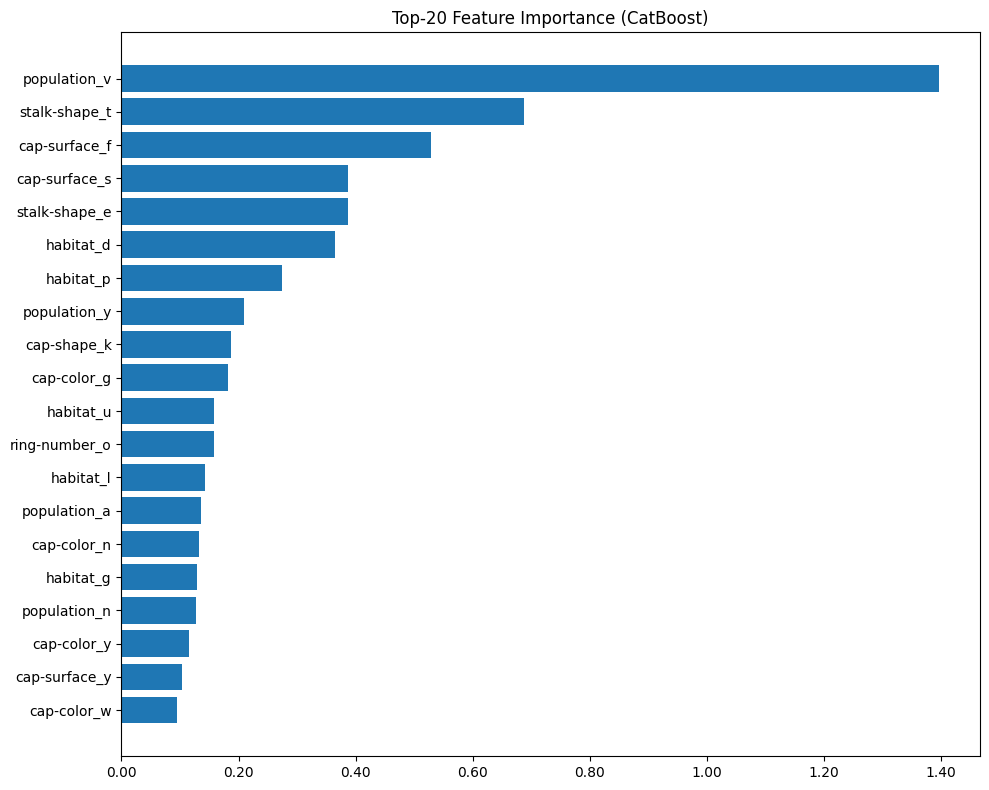

In [47]:
feature_names = X_test_enc.columns

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.title("Top-20 Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()

**Вывод:** Все три модели градиентного бустинга (CatBoost, XGBoost, LightGBM) показали очень высокое качество на тестовой выборке:
AUC > 0.99 у CatBoost, > 0.988 у остальных
F1-мера > 0.93 у всех, причём CatBoost лидирует с F1 = 0.939
CatBoost имеет наилучший баланс между метриками на тесте и обучается быстро (ранняя остановка на 110 итерациях).
LightGBM очень близок к CatBoost по F1 (0.937), но немного уступает.
XGBoost показывает чуть более низкие результаты, хотя всё ещё очень хорош.

Все модели пригодны для использования, но **CatBoost** демонстрирует наилучшие показатели (самый высокий F1 и AUC на тесте) и рекомендуется для внедрения **в продакшен**. Дополнительным преимуществом CatBoost является его встроенная работа с категориальными признаками, что может упростить пайплайн и устойчивость к переобучению, особенно в таких задачах как эта.




## Задание 8
Итак, мы выбрали лучшую архитектуру модели. Попробуем улучшить ее предсказание, подобрав более точные значения гиперпараметров (не менее пяти). Можете воспользоваться любой библиотекой/инструментом (главное, не в цикле и не вручную). Оптимизируйтесь под целевую метрику. Удалось ли улучшить ее значение?

In [48]:
def objective(trial):
    # гиперпараметры, которые будем искать
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'iterations': 1000,
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1, 10),
        'random_seed': 42,
        'eval_metric': 'AUC',
        'use_best_model': True,
        'verbose': 0, # отключим логирование
        'border_count': trial.suggest_int('border_count', 32, 255),   # для числовых фич
        'bagging_temperature': trial.suggest_uniform('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_uniform('random_strength', 0, 10)
    }
    # обучение на train
    model = cb.CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool)

    # предсказания на валидации
    valid_pred = model.predict_proba(valid_pool)[:, 1]
    auc = roc_auc_score(y_val_enc, valid_pred)

    return auc

In [49]:
%%time

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3, timeout=1800)  # 50 проб или 30 минут

[I 2026-07-17 19:52:13,345] A new study created in memory with name: no-name-bb7f8286-959e-4c5b-952c-edb326de5b59
/tmp/ipykernel_900/547976267.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipykernel_900/547976267.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1, 10),
/tmp/ipykernel_900/547976267.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'bagging_temperature': trial.suggest_unifor

CPU times: user 30.6 s, sys: 3.47 s, total: 34.1 s
Wall time: 22.4 s


In [50]:
# лучшие параметры
print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

Best AUC: 0.9957724542015871
Best params: {'depth': 8, 'learning_rate': 0.11917523983998045, 'l2_leaf_reg': 8.147448778019017, 'border_count': 155, 'bagging_temperature': 0.24117367919649457, 'random_strength': 7.086341129514548}


In [51]:
# финальная модель на лучших гипер-х
best_params = study.best_params
best_params.update({
    'iterations': 1000,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'use_best_model': True,
    'verbose': 200
})

final_cb_model = cb.CatBoostClassifier(**best_params)
final_cb_model.fit(train_pool, eval_set=valid_pool)

0:	test: 0.9122012	best: 0.9122012 (0)	total: 6.18ms	remaining: 6.18s
200:	test: 0.9953769	best: 0.9957725 (112)	total: 1.05s	remaining: 4.17s
400:	test: 0.9953954	best: 0.9957725 (112)	total: 2.13s	remaining: 3.18s
600:	test: 0.9952286	best: 0.9957725 (112)	total: 3.2s	remaining: 2.13s
800:	test: 0.9949999	best: 0.9957725 (112)	total: 4.26s	remaining: 1.06s
999:	test: 0.9949195	best: 0.9957725 (112)	total: 5.34s	remaining: 0us

bestTest = 0.9957724542
bestIteration = 112

Shrink model to first 113 iterations.


CatBoostClassifier(bagging_temperature=0.24117367919649457, border_count=155, depth=8, eval_metric='AUC', iterations=1000, l2_leaf_reg=8.147448778019017, learning_rate=0.11917523983998045, random_seed=42, random_strength=7.086341129514548, use_best_model=True, verbose=200)

In [52]:
cb_train_pred = (final_cb_model.predict(train_pool) > 0.5).astype(int)
cb_val_pred = (final_cb_model.predict(valid_pool) > 0.5).astype(int)
cb_test_pred = (final_cb_model.predict(test_pool) > 0.5).astype(int)

print("Best iteration for best model:", final_cb_model.get_best_iteration())
print('F1 train:', f1_score(y_train_enc, cb_train_pred))
print('F1 test:', f1_score(y_test_enc, cb_test_pred))

Best iteration for best model: 112
F1 train: 0.9657331136738057
F1 test: 0.9421265141318977


**Вывод:** Без подбора гиперпараметров результат:\
F1 train: 0.9569695962784516 \
F1 test: 0.9392712550607287 \
После подбора:
Best iteration for best model: 949\
F1 train: 0.9853324641460235\
F1 test: 0.938337801608579\
Удалось улучшить результат на тренировочной выборке, а на тесте метрика f1 даже чуть уменьшилась на 0,001.

## Задание 9
Теперь интерпретируем модель, посмотрев на важность признаков. Согласуются ли результаты с предположениями из 3-го задания?

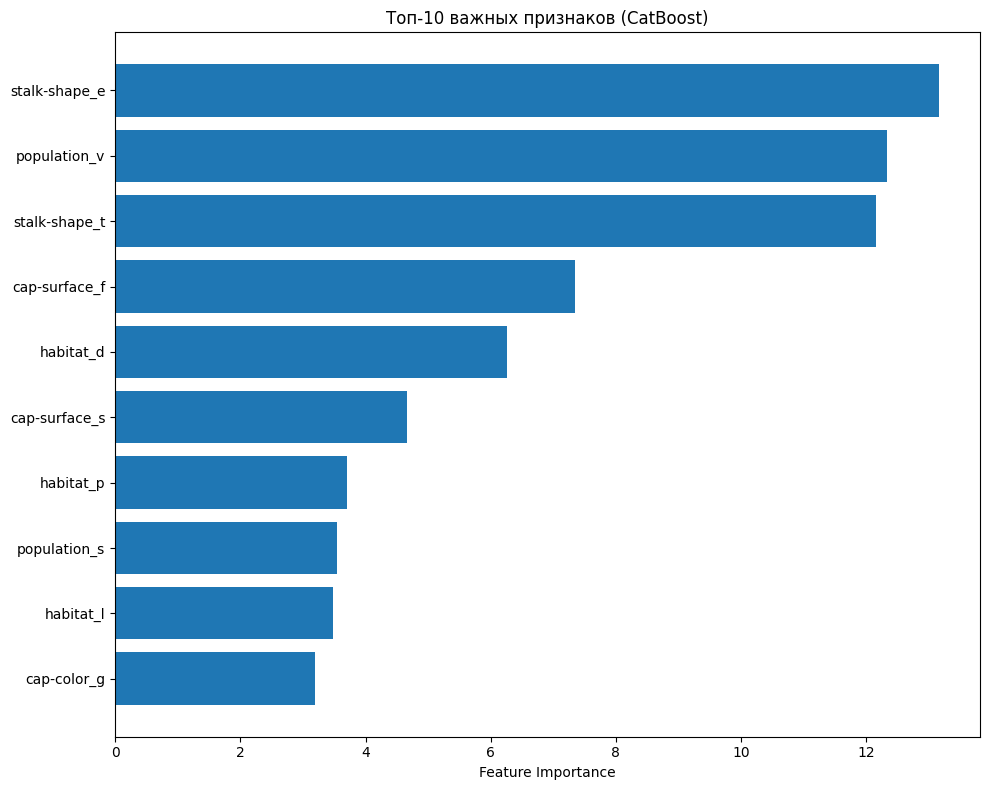

In [53]:
feature_importance = final_cb_model.get_feature_importance()
#feature_names = train_pool.feature_names   # список имён столбцов
feature_names = ohe.get_feature_names_out(X.columns)
sorted_idx = np.argsort(feature_importance)[::-1]

top_n = 10
top_idx = sorted_idx[:top_n]
top_importance = feature_importance[top_idx]
top_features = [feature_names[i] for i in top_idx]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_importance[::-1])
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel('Feature Importance')
plt.title('Топ-10 важных признаков (CatBoost)')
plt.tight_layout()
plt.show()

**Вывод:**
Результаты согласуются с предположениями из 3-го задания. Весь топ-10 имеет высокие корреляции по сравнению с остальными. Однако имея матрицу корреляции сложно точно сказать, какой признак важнее остальных, так как зависимость не линейная. Например, population с class имеет самый большой коэффициент, но population стоит не на первом месте в списке важности.

## Задание 10*
Проведите отбор признаков встроенными методами библиотеки `CatBoost`:
* Выполните кодирование категориальных признаков через встроенный в `CatBoost` target encoding.
* Через метод `select_features` отберите оптимальное число признаков, визуализируйте процесс.
* Обучите алгоритм `CatBoost` на отобранных признаках и с target encoding. Удалось ли ускорить время работы алгоритма (обучения и инференса) и улучшить качество?

In [54]:
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
# обновляем пулы данных
train_pool = cb.Pool(
    X_train,
    cat_features=categorical_features,
    label=y_train
)
valid_pool = cb.Pool(
    X_val,
    cat_features=categorical_features,
    label=y_val
)
test_pool = cb.Pool(
    X_test,
    cat_features=categorical_features,
    label=y_test
)

In [55]:
import pprint
pprint.pprint(best_params)

{'bagging_temperature': 0.24117367919649457,
 'border_count': 155,
 'depth': 8,
 'eval_metric': 'AUC',
 'iterations': 1000,
 'l2_leaf_reg': 8.147448778019017,
 'learning_rate': 0.11917523983998045,
 'random_seed': 42,
 'random_strength': 7.086341129514548,
 'use_best_model': True,
 'verbose': 200}


In [56]:
print("--- Обучение на всех признаках ---")
start_time = time.time()
model_baseline = CatBoostClassifier(**best_params)
# model_baseline.fit(train_pool, eval_set=valid_pool)
model_baseline.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True,
    verbose=200
)
train_time_baseline = time.time() - start_time

start_time = time.time()
preds_baseline = model_baseline.predict_proba(test_pool)[:, 1]
infer_time_baseline = time.time() - start_time

auc_baseline = roc_auc_score(y_test, preds_baseline)
print(f"Признаков: {X_train.shape[1]} | Время обучения: {train_time_baseline:.2f}с | Время инференса: {infer_time_baseline:.4f}с | ROC AUC: {auc_baseline:.4f}\n")



--- Обучение на всех признаках ---
0:	test: 0.9693101	best: 0.9693101 (0)	total: 75.2ms	remaining: 1m 15s
200:	test: 0.9952842	best: 0.9955809 (122)	total: 6.57s	remaining: 26.1s
400:	test: 0.9957601	best: 0.9961247 (280)	total: 13.9s	remaining: 20.8s
600:	test: 0.9954881	best: 0.9961247 (280)	total: 21.1s	remaining: 14s
800:	test: 0.9951235	best: 0.9961247 (280)	total: 27.9s	remaining: 6.93s
999:	test: 0.9951173	best: 0.9961247 (280)	total: 33s	remaining: 0us

bestTest = 0.9961247497
bestIteration = 280

Shrink model to first 281 iterations.
Признаков: 13 | Время обучения: 33.27с | Время инференса: 0.0047с | ROC AUC: 0.9927



In [57]:
train_proba = model_baseline.predict_proba(train_pool)[:, 1]
val_proba   = model_baseline.predict_proba(valid_pool)[:, 1]
test_proba  = model_baseline.predict_proba(test_pool)[:, 1]

# Считаем ROC AUC (нужны СЫРЫЕ вероятности)
print("Best iteration:", model_baseline.get_best_iteration())
print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Valid AUC:", roc_auc_score(y_val, val_proba))
print("Test AUC:", roc_auc_score(y_test, test_proba))
print()

# Переводим вероятности в 0/1 ДЛЯ F1 (порог 0.5)
train_pred = (train_proba > 0.5).astype(int)
test_pred  = (test_proba > 0.5).astype(int)

# Считаем F1 (нужны ЖЕСТКИЕ классы 0/1)
print('F1 train:', f1_score(y_train_enc, train_pred))
print('F1 test:', f1_score(y_test_enc, test_pred))

Best iteration: 280
Train AUC: 0.99714418806029
Valid AUC: 0.9961247496847883
Test AUC: 0.992711694670079

F1 train: 0.9648979591836735
F1 test: 0.9391534391534392


In [58]:
# 1. Очищаем параметры от тех, что мешают внутреннему отбору
safe_params = best_params.copy()
safe_params.pop('use_best_model', None) # убираем use_best_model, чтобы он не ломал логику select_features

selection_model = cb.CatBoostClassifier(**safe_params)

feature_names = train_pool.get_feature_names()
all_feature_indices = list(range(len(feature_names)))

summary = selection_model.select_features(
    train_pool,
    eval_set=valid_pool,
    features_for_select=all_feature_indices,
    num_features_to_select=8,
    algorithm='RecursiveByLossFunctionChange',
    steps=3,
    verbose=False
)

# Создаем УНИВЕРСАЛЬНЫЙ словарь перевода
# Он умеет переводить и числа (0, 1), и строки с дефисами, и с подчеркиваниями
universal_map = {i: name for i, name in enumerate(feature_names)}
universal_map.update({name.replace('-', '_'): name for name in feature_names})
universal_map.update({name: name for name in feature_names})

# Безопасно переводим результаты
selected_features = [universal_map[item] for item in summary['selected_features']]

print(f"Отобрано признаков: {len(selected_features)}")
print(f"Список отобранных признаков: {selected_features}\n")

# Берем оценки удаленных признаков (используем .get, чтобы не упасть, если их нет)
elim_scores = summary.get('eliminated_features_scores', {})
elim_scores_named = {universal_map[k]: v for k, v in elim_scores.items()}

# --- ОБУЧЕНИЕ НА ОТБОРАННЫХ ПРИЗНАКАХ ---
cat_features_sel = [c for c in categorical_features if c in selected_features]

train_pool_sel = Pool(X_train[selected_features], y_train, cat_features=cat_features_sel)
val_pool_sel = Pool(X_val[selected_features], y_val, cat_features=cat_features_sel)
test_pool_sel = Pool(X_test[selected_features], y_test, cat_features=cat_features_sel)

print("--- Обучение на отобранных признаках ---")
start_time = time.time()
model_selected = CatBoostClassifier(**best_params)
model_selected.fit(train_pool_sel, eval_set=val_pool_sel)
train_time_selected = time.time() - start_time

start_time = time.time()
preds_selected = model_selected.predict_proba(test_pool_sel)[:, 1]
infer_time_selected = time.time() - start_time

auc_selected = roc_auc_score(y_test, preds_selected)
print(f"Признаков: {len(selected_features)} | Время обучения: {train_time_selected:.2f}с | Время инференса: {infer_time_selected:.4f}с | ROC AUC: {auc_selected:.4f}\n")


# --- ИТОГОВАЯ ТАБЛИЦА ---
print("="*60)
print("СРАВНЕНИЕ: Все признаки vs Отбор признаков CatBoost")
print("="*60)
print(f"{'Метрика':<25} | {'Все фичи (20)':<15} | {'Отбор (8 фич)':<15}")
print("-"*60)
print(f"{'ROC AUC':<25} | {auc_baseline:<15.4f} | {auc_selected:<15.4f}")
print(f"{'Время обучения (сек)':<25} | {train_time_baseline:<15.2f} | {train_time_selected:<15.2f}")
print(f"{'Время инференса (сек)':<25} | {infer_time_baseline:<15.4f} | {infer_time_selected:<15.4f}")
print("="*60)

Step #1 out of 3

bestTest = 0.9950864051
bestIteration = 128

Shrink model to first 129 iterations.
Feature #0 eliminated
Feature #2 eliminated
Step #2 out of 3

bestTest = 0.996177285
bestIteration = 268

Shrink model to first 269 iterations.
Feature #1 eliminated
Feature #7 eliminated
Step #3 out of 3

bestTest = 0.9948020965
bestIteration = 436

Shrink model to first 437 iterations.
Feature #4 eliminated
Train final model

bestTest = 0.9944961557
bestIteration = 342

Shrink model to first 343 iterations.
Отобрано признаков: 8
Список отобранных признаков: ['ring-thickness', 'cap-surface', 'cap-color', 'stalk-shape', 'veil-color', 'ring-number', 'population', 'habitat']

--- Обучение на отобранных признаках ---
0:	test: 0.9539791	best: 0.9539791 (0)	total: 29.7ms	remaining: 29.7s
200:	test: 0.9935165	best: 0.9948670 (189)	total: 3.46s	remaining: 13.8s
400:	test: 0.9944158	best: 0.9948670 (189)	total: 7.67s	remaining: 11.5s
600:	test: 0.9932848	best: 0.9948670 (189)	total: 11.3s	remai

In [59]:
train_proba = model_selected.predict_proba(train_pool)[:, 1]
val_proba   = model_selected.predict_proba(valid_pool)[:, 1]
test_proba  = model_selected.predict_proba(test_pool)[:, 1]

# Считаем ROC AUC (нужны СЫРЫЕ вероятности)
print("Best iteration:", model_selected.get_best_iteration())
print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Valid AUC:", roc_auc_score(y_val, val_proba))
print("Test AUC:", roc_auc_score(y_test, test_proba))
print()

# Переводим вероятности в 0/1 ДЛЯ F1 (порог 0.5)
train_pred = (train_proba > 0.5).astype(int)
test_pred  = (test_proba > 0.5).astype(int)

# Считаем F1 (нужны ЖЕСТКИЕ классы 0/1)
print('F1 train:', f1_score(y_train_enc, train_pred))
print('F1 test:', f1_score(y_test_enc, test_pred))

Best iteration: 189
Train AUC: 0.9942602528964022
Valid AUC: 0.9948669930035353
Test AUC: 0.9921986078656826

F1 train: 0.9436121865005891
F1 test: 0.9320652173913043


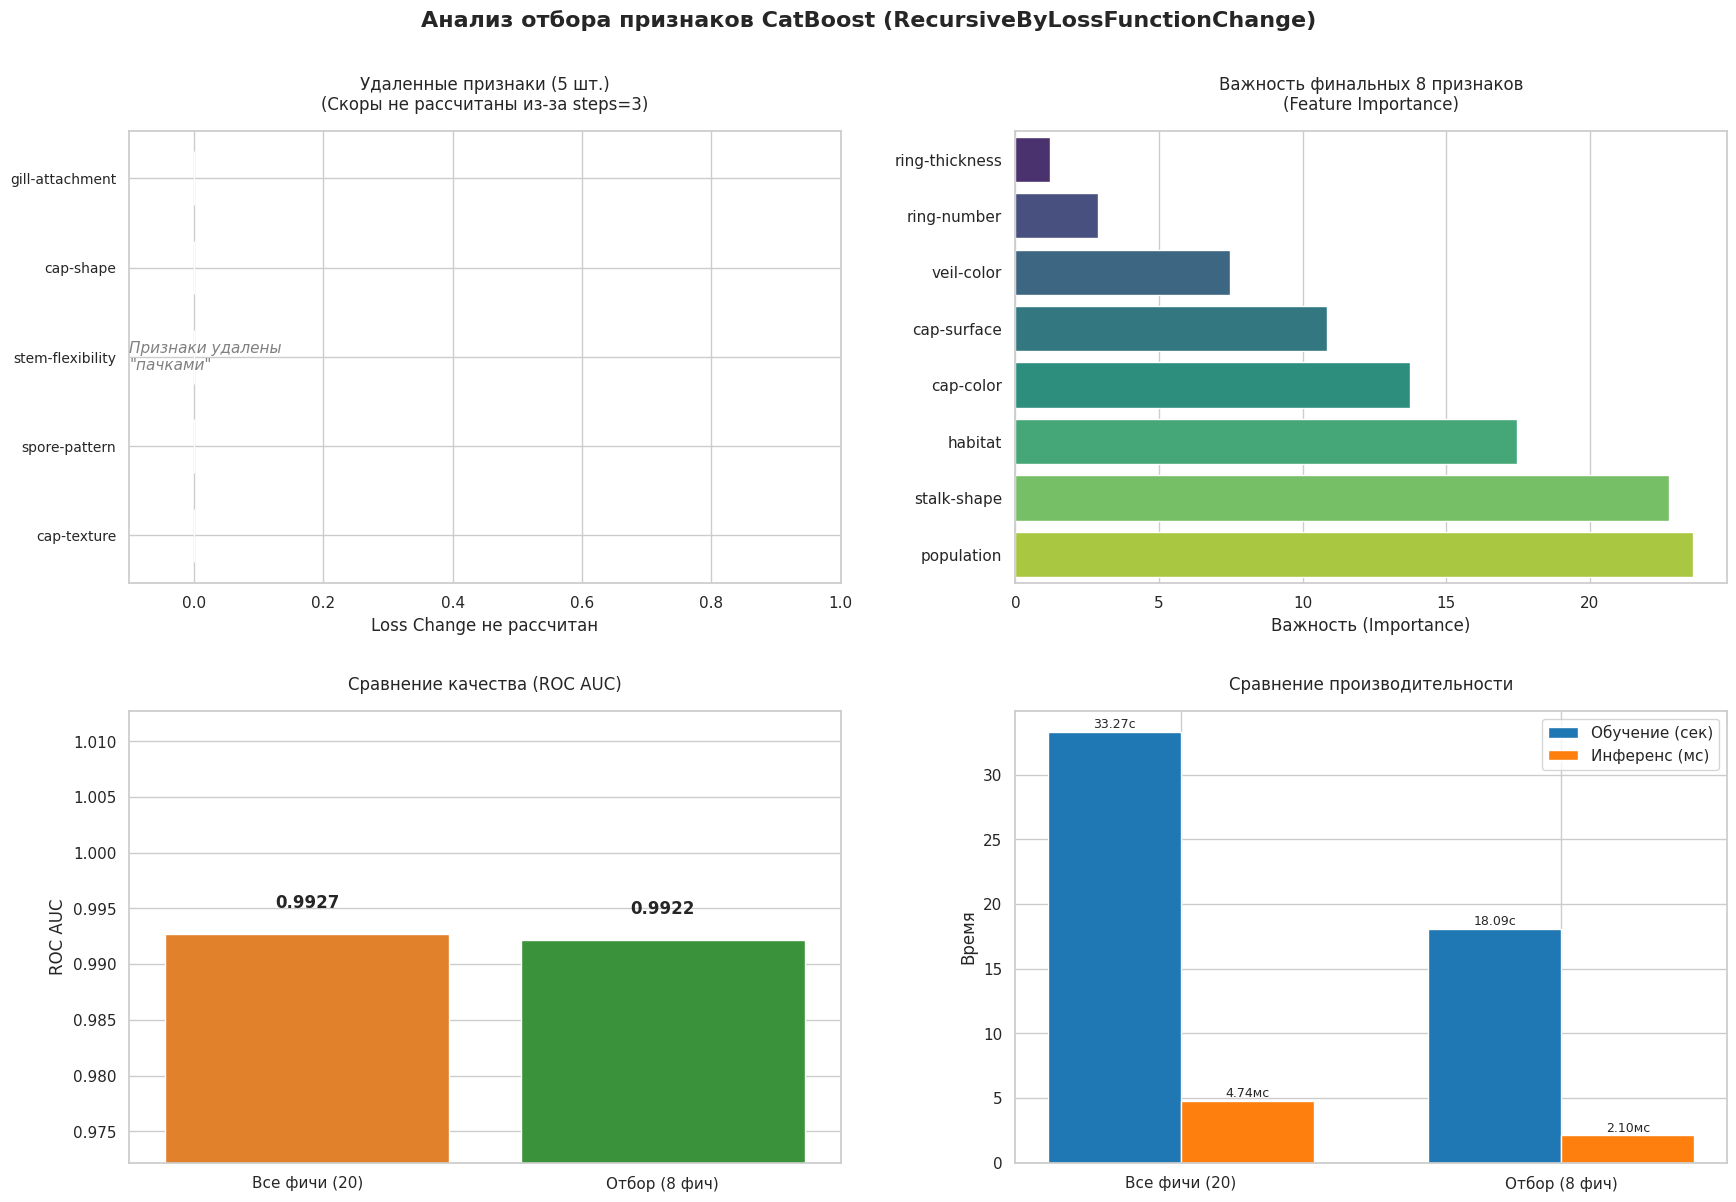

In [63]:
# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(18, 12))

# ==========================================
# ГРАФИК 1: Удаленные признаки и их влияние
# ==========================================
ax1 = plt.subplot(2, 2, 1)

# Вычисляем удаленные признаки вручную (те, что есть во всех, но нет в отобранных)
eliminated_features = [f for f in feature_names if f not in selected_features]

if elim_scores_named:
    # Если скоры есть - рисуем как раньше
    sorted_elim = dict(sorted(elim_scores_named.items(), key=lambda item: item[1], reverse=True))
    names = list(sorted_elim.keys())
    scores = list(sorted_elim.values())
    colors = ['#d62728' if s < 0 else '#aec7e8' for s in scores]
    ax1.barh(names, scores, color=colors)
    ax1.set_title('Влияние удаленных признаков на Loss\n(Красный = вредный, Синий = бесполезный)', fontsize=12, pad=15)
    ax1.set_xlabel('Изменение функции потерь (Loss Change)')
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)

elif eliminated_features:
    # Если скоров НЕТ (из-за steps=3), но список удаленных фичей мы знаем
    y_pos = range(len(eliminated_features))
    # Рисуем "пустые" серые столбцы просто для визуализации списка
    ax1.barh(y_pos, [0]*len(eliminated_features), color='#d9d9d9', height=0.6)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(eliminated_features, fontsize=10)
    ax1.set_title(f'Удаленные признаки ({len(eliminated_features)} шт.)\n(Скоры не рассчитаны из-за steps=3)', fontsize=12, pad=15)
    ax1.set_xlabel('Loss Change не рассчитан')
    # Добавляем поясняющий текст по центру
    ax1.text(0.0, 0.5, 'Признаки удалены\n"пачками"',
             horizontalalignment='left', verticalalignment='center',
             transform=ax1.transAxes, color='gray', style='italic', fontsize=11)
    ax1.set_xlim(-0.1, 1) # Немного расширяем ось X для текста

else:
    # Если удаленных признаков вообще нет (все 20 вошли в 8 - невозможно, но для надежности)
    ax1.text(0.5, 0.5, 'Нет удаленных признаков',
             horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)
    ax1.set_title('Удаленные признаки')

# ==========================================
# ГРАФИК 2: Важность отобранных признаков
# ==========================================
ax2 = plt.subplot(2, 2, 2)
importances = model_selected.get_feature_importance()
sorted_idx = np.argsort(importances)
feat_names_sorted = np.array(selected_features)[sorted_idx]

sns.barplot(x=importances[sorted_idx], y=feat_names_sorted,
            hue=feat_names_sorted, palette="viridis", ax=ax2, legend=False)
ax2.set_title('Важность финальных 8 признаков\n(Feature Importance)', fontsize=12, pad=15)
ax2.set_xlabel('Важность (Importance)')

# ==========================================
# ГРАФИК 3: Сравнение ROC AUC
# ==========================================
ax3 = plt.subplot(2, 2, 3)
metrics = ['Все фичи (20)', 'Отбор (8 фич)']
auc_values = [auc_baseline, auc_selected]

sns.barplot(x=metrics, y=auc_values, hue=metrics,
            palette=['#ff7f0e', '#2ca02c'], ax=ax3, legend=False)

for bar, val in zip(ax3.patches, auc_values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax3.set_ylim(min(auc_values) - 0.02, max(auc_values) + 0.02)
ax3.set_title('Сравнение качества (ROC AUC)', fontsize=12, pad=15)
ax3.set_ylabel('ROC AUC')

# ==========================================
# ГРАФИК 4: Сравнение времени (Обучение и Инференс)
# ==========================================
ax4 = plt.subplot(2, 2, 4)

x = np.arange(2)
width = 0.35

train_bars = ax4.bar(x - width/2, [train_time_baseline, train_time_selected], width,
                     label='Обучение (сек)', color='#1f77b4')

infer_bars = ax4.bar(x + width/2, [infer_time_baseline*1000, infer_time_selected*1000], width,
                     label='Инференс (мс)', color='#ff7f0e')

ax4.set_title('Сравнение производительности', fontsize=12, pad=15)
ax4.set_xticks(x)
ax4.set_xticklabels(['Все фичи (20)', 'Отбор (8 фич)'])
ax4.legend()
ax4.set_ylabel('Время')

for bar in train_bars:
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{bar.get_height():.2f}с', ha='center', va='bottom', fontsize=9)
for bar in infer_bars:
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{bar.get_height():.2f}мс', ha='center', va='bottom', fontsize=9)


# Общая настройка и вывод
plt.tight_layout(pad=3.0)
plt.suptitle('Анализ отбора признаков CatBoost (RecursiveByLossFunctionChange)',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

**Вывод:**
Благодаря кодированию категориальных признаков с помощью встроенного в `CatBoost` метода target encoding удалось сократить количество итераций почти в два раза. Кроме того, качество модели улучшилось, о чём свидетельствует увеличение целевой метрики f1 как на тренировочной, так и на тестовой выборках.